In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

import warnings
warnings.filterwarnings('ignore')

In [27]:
X, y = make_blobs(n_samples=1000, centers=4, cluster_std=0.5, random_state=0)

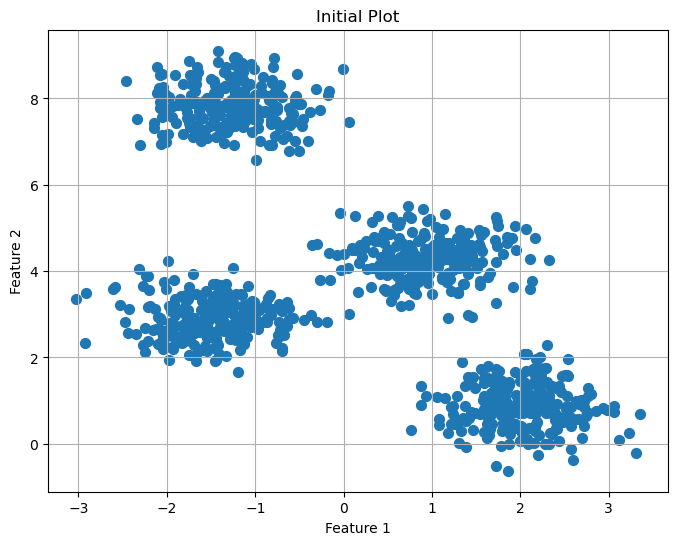

In [28]:
plt.figure(figsize=(8, 6));
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis');
plt.title('Initial Plot');
plt.xlabel('Feature 1');
plt.ylabel('Feature 2');
plt.grid(True);

['y', 'b', 'g', 'r']


Text(0.5, 1.0, 'number of clusters: 4')

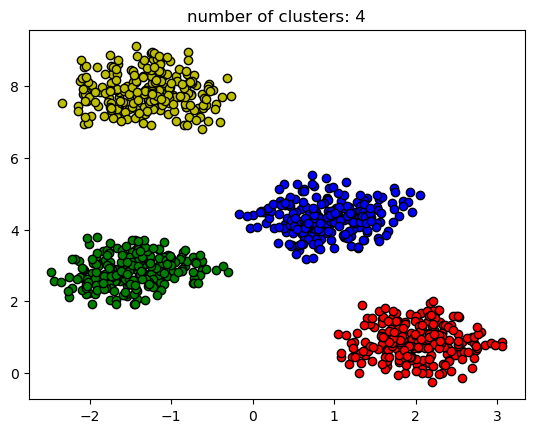

In [29]:
model = DBSCAN(eps=0.3, min_samples=10).fit(X);

core_samples_mask = np.zeros_like(model.labels_, dtype=bool)
core_samples_mask[model.core_sample_indices_] = True

labels = model.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
	if k == -1:
		# Black used for noise.
		col = 'k'

	class_member_mask = (labels == k)

	xy = X[class_member_mask & core_samples_mask]
	plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = X[class_member_mask & ~core_samples_mask]
	plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('number of clusters: %d' % n_clusters_)

In [30]:
from sklearn.metrics import adjusted_rand_score

# evaluation metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.67
Adjusted Rand Index: 0.91
